In [1]:
import xarray as xr
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

First join lat/lon points in ERA5 grid to Polygons (points) described in shapefile as a single df, then merge the geospatial df to the multidim (with time dim) dataset (converted to df) by lat lon. 

1. load netcdf - ensure lon -180:180
2. load shapefile - ensure format in espg:4326 - can you tell me why this format? and importance of this format
3. create geodataframe points based on netcdf lat/lon.
4.  Handle border & missing county cases
5. do sjoin between shapefile and points

In [16]:
path = '/data/keeling/a/rytam2/a/iema_output/arcgis_toprocess/feb14_2026/'
save_path = '/data/keeling/a/rytam2/a/iema_output/era5/arcgis_toprocess/'

fname = 'daily_wbgt_by_county_2016-2025'#grab filename

In [12]:
# Step1: ERA5 
ds = xr.open_mfdataset(path+fname+'.nc').drop_vars('county')
if ds["lon"].values.max() > 180:
    ds = ds.assign_coords(lon=(ds["lon"]+180) % 360 - 180)
    ds = ds.sortby("lon")

# Step2: County Shape File 
gdf_counties = gpd.read_file("/data/keeling/a/rytam2/climstat/local/county_zc_shpfile/county/tl_2025_us_county.shp")
gdf_counties_il = gdf_counties[gdf_counties['STATEFP'] == '17'].reset_index(drop=True)

if gdf_counties_il.crs.to_epsg() != 4326:
    gdf_counties_il = gdf_counties_il.to_crs("EPSG:4326")

In [13]:
# Step3: geodataframe of all era5 location points
lons, lats = np.meshgrid(ds.lon.values, ds.lat.values)
points_df = pd.DataFrame({
    'lat': lats.flatten(),
    'lon': lons.flatten()
})
points_df = points_df.drop_duplicates()

geometry = [Point(lon, lat) for lon, lat in zip(points_df.lon, points_df.lat)]
points_gdf = gpd.GeoDataFrame(points_df, geometry=geometry, crs="EPSG:4326")

In [14]:
# Step 4: Handle border & missing county cases
joined = gpd.sjoin(points_gdf, gdf_counties_il, how="inner", predicate="within") #predicate=within/intersects (if points from sjoin are the same for both method, no overlapping points in multiple counties.)

# Check points within IL's lat/lon range? (predicate within/intersects)
rough_il = points_df[
    (points_df.lon >= -91.6) & (points_df.lon <= -87.0) &
    (points_df.lat >= 36.9) & (points_df.lat <= 42.6)
]
print(f"Points roughly in IL bounding box: {len(rough_il)}")
print(f"Points from sjoin: {len(joined)}")

# check if all counties have a point 
counts = joined.groupby(['GEOID', 'NAME']).size().sort_values().head(20)
# and if all points land on a county 
counts = joined.groupby(['lat', 'lon']).size()
print(counts.value_counts().rename_axis('counties_per_point').rename('num_points'))

Points roughly in IL bounding box: 437
Points from sjoin: 246
counties_per_point
1    246
Name: num_points, dtype: int64


In [15]:
# ── Step 4: Merge with full time-series data ──
df = ds.to_dataframe().reset_index()
result = df.merge(
    joined[['lat', 'lon', 'NAMELSAD', 'GEOID']],
    on=['lat', 'lon'],
    how='inner' #leave out grid points that is in ds but not joined 
)

In [17]:
# save file #now pipelineable 
result.sort_values('NAMELSAD').to_csv(save_path+fname+'.csv', index=False)#['GEOID'].unique() # save to csv 

#### Check

In [73]:
# for invalid geometries
invalid = gdf_counties_il[~gdf_counties_il.is_valid]
print(f"Invalid geometries: {len(invalid)}")

Invalid geometries: 0


In [74]:
print(f"Unique lat/lon combinations: {df[['lat','lon']].drop_duplicates().shape[0]}")
print(f"Total rows in gdf_points: {len(gdf_points)}")
print(f"Number of timesteps: {df['time'].nunique()}")

Unique lat/lon combinations: 783


NameError: name 'gdf_points' is not defined

In [ ]:
print(type(gdf_points.geometry.iloc[0]))
print(gdf_points.geometry.iloc[0])
print(gdf_points.geometry.is_valid.all())
print(gdf_points.geometry.is_empty.any())

In [ ]:
# Check for unmatched ERA5 points (fell outside all counties)
unmatched_points = gdf_joined["GEOID"].isna().sum()
print(f"Unmatched ERA5 points: {unmatched_points}")

# Check for counties with no ERA5 point inside them
matched_counties = gdf_joined["GEOID"].nunique()
total_counties = gdf_counties["GEOID"].nunique()
print(f"Counties with no ERA5 point: {total_counties - matched_counties}")

In [66]:
# How many points visually fall within IL's lat/lon range?
rough_il = points_df[
    (points_df.longitude >= -91.6) & (points_df.longitude <= -87.0) &
    (points_df.latitude >= 36.9) & (points_df.latitude <= 42.6)
]
print(f"Points roughly in IL bounding box: {len(rough_il)}")
print(f"Points from sjoin: {len(joined)}")

print("Lat spacing:", np.diff(ds.lat.values[:3]))
print("Lon spacing:", np.diff(ds.lon.values[:3]))
print("Total lats:", len(ds.lat))
print("Total lons:", len(ds.lon))

Points roughly in IL bounding box: 437
Points from sjoin: 246
Lat spacing: [-0.25 -0.25]
Lon spacing: [0.25 0.25]
Total lats: 29
Total lons: 27


In [67]:
all_lons = lons.flatten()
all_lats = lats.flatten()

# IL bounding box from county bounds
minx, miny, maxx, maxy = gdf_counties_il.total_bounds  # [-91.51, 36.97, -87.02, 42.51]

# Classify points
in_bbox = (
    (all_lons >= minx) & (all_lons <= maxx) &
    (all_lats >= miny) & (all_lats <= maxy)
)
in_county_set = set(zip(joined.longitude.round(6), joined.latitude.round(6)))
in_county = np.array([
    (round(lon, 6), round(lat, 6)) in in_county_set
    for lon, lat in zip(all_lons, all_lats)
])

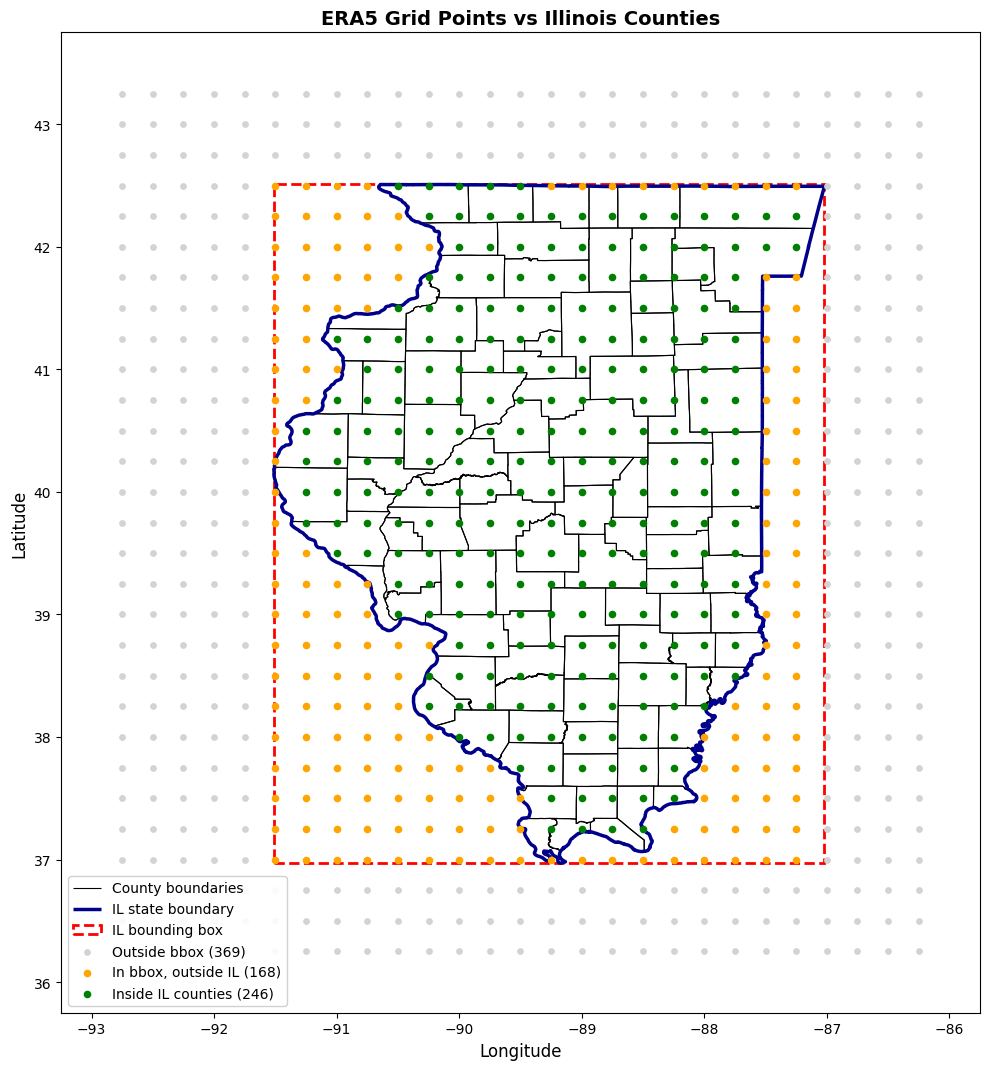

Plot saved to era5_il_grid_plot.png


In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 12))

# 1. IL county boundaries
gdf_counties_il.boundary.plot(ax=ax, linewidth=0.8, color="black", label="County boundaries")

# 2. IL state outline (dissolve all counties)
state = gdf_counties_il.dissolve()
state.boundary.plot(ax=ax, linewidth=2.5, color="darkblue", label="IL state boundary")

# 3. IL bounding box
bbox_rect = mpatches.Rectangle(
    (minx, miny), maxx - minx, maxy - miny,
    linewidth=2, edgecolor="red", facecolor="none", linestyle="--", label="IL bounding box"
)
ax.add_patch(bbox_rect)

# 4. Grid points — three categories
# Outside bounding box
mask_outside = ~in_bbox & ~in_county
ax.scatter(all_lons[mask_outside], all_lats[mask_outside],
           c="lightgray", s=15, zorder=2, label=f"Outside bbox ({mask_outside.sum()})")

# Inside bounding box but outside IL
mask_bbox_only = in_bbox & ~in_county
ax.scatter(all_lons[mask_bbox_only], all_lats[mask_bbox_only],
           c="orange", s=20, zorder=3, label=f"In bbox, outside IL ({mask_bbox_only.sum()})")

# Inside IL counties
ax.scatter(all_lons[in_county], all_lats[in_county],
           c="green", s=20, zorder=4, label=f"Inside IL counties ({in_county.sum()})")

# Formatting
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("ERA5 Grid Points vs Illinois Counties", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=10, framealpha=0.9)
ax.set_aspect("equal")

# Extend axes slightly beyond ERA5 grid
pad = 0.5
ax.set_xlim(all_lons.min() - pad, all_lons.max() + pad)
ax.set_ylim(all_lats.min() - pad, all_lats.max() + pad)

plt.tight_layout()
# plt.savefig("era5_il_grid_plot.png", dpi=150, bbox_inches="tight")
plt.show()